# 08. Функции потерь для регрессии: L2, L1, Хьюбер, квантиль — на данных с выбросами

| | |
|---|---|
| **Уровень** | 2 из 4 — маленькие данные: реальные наборы и базовые приёмы (`2_small`) |
| **Скрипт-источник** | [`08_loss_functions_outliers.py`](../08_loss_functions_outliers.py) — тот же код, запуск из терминала |
| **Время выполнения** | ≈ 4 с |

**Цель.** Понять, как выбор потери меняет модель, и научиться выбирать её под задачу.

### Чему вы научитесь

- Чувствительность L2 к выбросам
- Устойчивость L1 и Хьюбера
- Квантильная регрессия для «верхней границы»
- Какая метрика соответствует какой потере

### Данные

1000 точек волны с растущим шумом, у 3% обучающих объектов y испорчен на +8…+12 (сбой датчика). Проверка — на чистых данных.

### План

1. **Этап 1.** Данные: волна, шум растёт с x, 3% выбросов вверх в обучении
2. **Этап 2.** Обучение: 300 деревьев глубины 3, ν = 0.05, минимум 10 объектов в листе
3. **Этап 3.** Ошибка на чистом тесте
4. **Этап 4.** Квантильная регрессия: 10-й и 90-й процентили — коридор, в который попадает 80% объектов
5. **Этап 5.** Картинка

> Ноутбук собран из `examples/2_small/08_loss_functions_outliers.py` командой `python examples/build_notebooks.py`. Чтобы изменить пример, правьте скрипт и пересоберите ноутбук.

## Подготовка

Ячейка ниже находит папку `examples/` (ноутбук можно открыть из любой рабочей папки внутри
репозитория), подключает общий каркас примеров `_common.Example` и учебную библиотеку курса
`gbcourse`. Каркас печатает этапы и выводы, «раскрывает» датасет и показывает графики прямо в
ноутбуке. Выполняйте ячейки сверху вниз: **Run → Run All Cells**.

In [1]:
import sys
from pathlib import Path

EXAMPLES = next(p / "examples" for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "examples" / "_common.py").is_file())
sys.path.insert(0, str(EXAMPLES))
from _common import Example

ex = Example(EXAMPLES / "2_small/08_loss_functions_outliers.py", title="08. Потери L2, L1, Хьюбер, квантиль на данных с выбросами",
             goal="увидеть, как потеря меняет модель, и выбрать её под задачу")

import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor

## Этап 1. Данные: волна, шум растёт с x, 3% выбросов вверх в обучении

In [2]:
rng = np.random.default_rng(8)
n = ex.size(1000, 400)
f = lambda x: np.sin(x) + 0.3 * x
x_tr = rng.uniform(0, 10, n)
y_tr = f(x_tr) + rng.normal(0, 0.2 + 0.05 * x_tr)
bad = rng.random(n) < 0.03
y_tr[bad] += rng.uniform(8, 12, bad.sum())
x_te = rng.uniform(0, 10, 5000)
y_te = f(x_te) + rng.normal(0, 0.2 + 0.05 * x_te)
ex.describe(x_tr[:, None], y_tr, names=["x"], target="y", source="синтетика")
print(f"   выбросов в обучении: {bad.sum()}")

   Источник: синтетика
   Объектов: 1 000   признаков: 1   память: 0.01 МБ
   Типы признаков: float64 × 1
   Пропусков нет
   Цель «y»: среднее 1.837, σ 1.887, мин -0.681, макс 14.804
   Первые строки:


,x,[y]
0,3.269723,0.634565
1,9.872768,0.800422
2,3.187108,0.989297


   выбросов в обучении: 23


## Этап 2. Обучение: 300 деревьев глубины 3, ν = 0.05, минимум 10 объектов в листе

In [3]:
P = dict(n_estimators=300, learning_rate=0.05, max_depth=3, min_samples_leaf=10, random_state=0)
models = {
    "L2 (squared_error)": GradientBoostingRegressor(loss="squared_error", **P),
    "L1 (absolute_error)": GradientBoostingRegressor(loss="absolute_error", **P),
    "Хьюбер (huber)": GradientBoostingRegressor(loss="huber", alpha=0.9, **P),
}
for m in models.values():
    m.fit(x_tr[:, None], y_tr)

## Этап 3. Ошибка на чистом тесте

In [4]:
res = {}
for name, m in models.items():
    p = m.predict(x_te[:, None])
    res[name] = (np.sqrt(np.mean((y_te - p) ** 2)), np.mean(np.abs(y_te - p)), np.mean(p - f(x_te)))
    print(f"   {name:20s} RMSE {res[name][0]:.3f}, MAE {res[name][1]:.3f}, среднее смещение {res[name][2]:+.3f}")
ex.note("""L2 гонится за выбросами: её прогноз смещён вверх. L1 и Хьюбер почти не замечают 3% испорченных точек.
Правило: какой метрикой будут оценивать, ту потерю (или устойчивую к грязи её версию) и оптимизируйте.""")
assert res["L2 (squared_error)"][2] > res["L1 (absolute_error)"][2]

   L2 (squared_error)   RMSE 0.669, MAE 0.470, среднее смещение +0.229
   L1 (absolute_error)  RMSE 0.487, MAE 0.369, среднее смещение -0.003
   Хьюбер (huber)       RMSE 0.495, MAE 0.375, среднее смещение +0.018


> ▸ **Вывод.** L2 гонится за выбросами: её прогноз смещён вверх. L1 и Хьюбер почти не замечают 3% испорченных точек. Правило: какой метрикой будут оценивать, ту потерю (или устойчивую к грязи её версию) и оптимизируйте.

## Этап 4. Квантильная регрессия: 10-й и 90-й процентили — коридор, в который попадает 80% объектов

In [5]:
q = {a: GradientBoostingRegressor(loss="quantile", alpha=a, **P).fit(x_tr[:, None], y_tr) for a in (0.1, 0.9)}
lo, hi = q[0.1].predict(x_te[:, None]), q[0.9].predict(x_te[:, None])
cover = np.mean((y_te >= lo) & (y_te <= hi))
print(f"   доля тестовых объектов внутри коридора: {cover:.3f} (цель 0.80); ширина растёт с x: "
      f"{np.mean((hi - lo)[x_te < 3]):.2f} при x < 3 и {np.mean((hi - lo)[x_te > 7]):.2f} при x > 7")
ex.note("Коридор расширяется там, где шум больше. Гарантии покрытия у квантилей нет — её даёт конформный метод (пример 26).")

   доля тестовых объектов внутри коридора: 0.788 (цель 0.80); ширина растёт с x: 1.01 при x < 3 и 2.04 при x > 7


> ▸ **Вывод.** Коридор расширяется там, где шум больше. Гарантии покрытия у квантилей нет — её даёт конформный метод (пример 26).

## Этап 5. Картинка

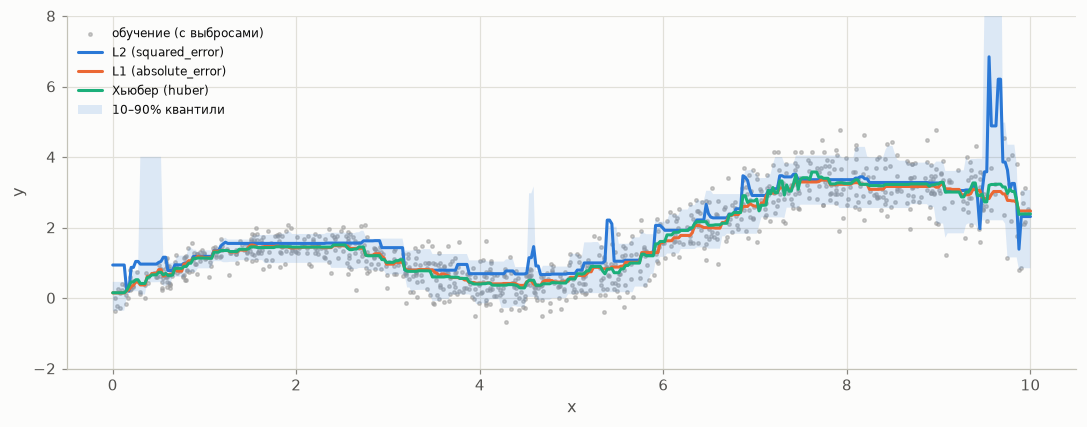

Готово за 2.4 с


In [6]:
g = np.linspace(0, 10, 400)[:, None]
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(x_tr, y_tr, s=5, color="#999", alpha=0.5, label="обучение (с выбросами)")
for name, m in models.items():
    ax.plot(g[:, 0], m.predict(g), lw=2, label=name)
ax.fill_between(g[:, 0], q[0.1].predict(g), q[0.9].predict(g), alpha=0.15, label="10–90% квантили")
ax.set(ylim=(-2, 8), xlabel="x", ylabel="y")
ax.legend(fontsize=8)
fig.tight_layout()
ex.finish(fig, "08_losses")
ex.done()

## Попробуйте сами

Измените код в ячейках выше и выполните их заново:

1. Увеличьте долю выбросов с 3% до 15% — какая потеря «ломается» первой?
2. Переберите alpha у `loss="huber"` и найдите лучшее значение по RMSE на тесте.
3. Постройте коридор 5%–95% и проверьте, какую долю точек он покрывает.

## Что дальше

- **Теория в курсе:** [5.3 «Потери для регрессии»](../../../lessons/lesson_5_3/README.md), [10.2 «Пропуски, выбросы, дисбаланс»](../../../lessons/lesson_10_2/README.md).
- **Предыдущий пример:** [07. Реальные данные «Рак груди» (569 опухолей): бинарная классификация и выбор порога](07_breast_cancer_classification.ipynb)
- **Следующий пример:** [09. Многоклассовая классификация: реальные данные «Вино» (178 образцов, 3 сорта)](09_multiclass_wine.ipynb)
- **Все примеры:** [examples/README.md](../../README.md)